In [ ]:
import sys
from pathlib import Path
# Add project root to sys.path so 'src.*' imports resolve correctly
sys.path.insert(0, str(Path("../..").resolve()))

In [12]:
# --- Core ---
import os
import json
import numpy as np

from src.data_prep import PrepAndDataLoader
from src.model_wrapper import Model, set_global_seed

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# === HHN-Thesis Plot Style ===
def set_hhn_plot_style():
    plt.style.use('default')
    mpl.rcParams.update({
        # Schrift & Text
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
        'font.size': 11,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,

        # Linien
        'lines.linewidth': 1.4,
        'lines.markersize': 4,

        # Farben
        'axes.prop_cycle': mpl.cycler(color=[
            '#003366',  # HHN-Blau (primär)
            '#999999',  # neutral Grau
            '#0072B2',  # heller Blauton für Vergleiche
            '#CC0000',  # Akzentrot für negative Werte / RMSE etc.
            '#56B4E9',  # hellblau (z. B. für Sentiment)
        ]),

        # Achsen & Gitter
        'axes.edgecolor': '#333333',
        'axes.linewidth': 0.8,
        'axes.grid': True,
        'grid.color': '#cccccc',
        'grid.linestyle': '--',
        'grid.linewidth': 0.6,

        # Hintergrund
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',

        # Legende
        'legend.frameon': False,
        'legend.loc': 'best',

        # Savefig
        'savefig.dpi': 300,
        'savefig.bbox': 'tight'
    })

set_hhn_plot_style()

In [14]:
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.mean(np.abs(a - b)))

def r2(a: np.ndarray, b: np.ndarray) -> float:
    ss_res = np.sum((a - b) ** 2)
    ss_tot = np.sum((a - a.mean()) ** 2)
    return float(1.0 - ss_res/ss_tot) if ss_tot > 0 else 0.0

def plot_history_from_json(history_json_path: str, title: str = ""):
    """Liest die vom Trainer gespeicherte History (JSON) und plottet Loss/Val-Loss."""
    if not os.path.isfile(history_json_path):
        print(f"[WARN] History file not found: {history_json_path}")
        return
    with open(history_json_path, "r") as f:
        hist = json.load(f)

    plt.figure()
    if "loss" in hist:
        plt.plot(hist["loss"], label="train_loss")
    if "val_loss" in hist:
        plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"Training History {title}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_sample(y_true_level: np.ndarray, y_pred_level: np.ndarray, title: str = "", save_path: str | None = None):
    """Plottet einen Test-Sample (Horizon-Kurve). y_*: shape [H]."""
    fig = plt.figure(facecolor="white")
    ax = fig.add_subplot(111)
    ax.plot(y_true_level, label="True")
    ax.plot(y_pred_level, label="Pred")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    if save_path:
        ensure_dir(os.path.dirname(save_path))
        plt.savefig(save_path, dpi=140)
        plt.close(fig)
    else:
        plt.show()

In [15]:
# Pfad ggf. anpassen
CONFIG = json.load(open("../../config.json"))
set_global_seed(CONFIG["random_seed"])

CSV_PATH = CONFIG["data"]["files"][0]
print("Using CSV:", CSV_PATH)

# Komfortvariablen
cols        = CONFIG["data"]["columns"]
target_col  = CONFIG["data"]["target_col"]
train_split = CONFIG["data"]["training_split"]
val_split   = CONFIG["data"]["validation_split"]
WINDOW      = int(CONFIG["data"]["window_size"])
H           = int(CONFIG["data"]["horizons"][0])   #[1,3,5,10,15]
NORMALISE   = CONFIG["data"]["normalise"]
NORM_METHOD = CONFIG["data"]["norm_method"]
STRIDE      = int(CONFIG["data"].get("stride", 1))

print(f"Window={WINDOW}, Horizon={H}, Norm={NORM_METHOD}, Columns={cols}")


Using CSV: ../data/ts_with_sentiment/AAPL_ts_with_sentiment.csv
Window=60, Horizon=1, Norm=percentage, Columns=['Close']


In [16]:
dl = PrepAndDataLoader(
    filename=CSV_PATH,
    training_split=train_split,
    validation_split=val_split,
    cols=cols,
    target_col=target_col,
    dtype="float32",
)

X_tr, y_tr, b_tr, bT_tr = dl.get_train_data(
    normalise=NORMALISE,
    window_size=WINDOW,
    prediction_range=H,
    norm_method=NORM_METHOD,
    stride=STRIDE,
)
X_va, y_va, b_va, bT_va = dl.get_validation_data(
    normalise=NORMALISE,
    window_size=WINDOW,
    prediction_range=H,
    norm_method=NORM_METHOD,
    stride=STRIDE,
)
X_te, y_te, b_te, bT_te = dl.get_test_data(
    normalise=NORMALISE,
    window_size=WINDOW,
    prediction_range=H,
    norm_method=NORM_METHOD,
    stride=STRIDE,
)

dates_te = dl.get_prediction_dates(
    "test",
    window_size=WINDOW,
    prediction_range=H,
    stride=STRIDE,
)  # [N, H] of datetime-like values

print("Shapes ->",
      "X_train", X_tr.shape, "y_train", y_tr.shape,
      "| X_validation", X_va.shape, "y_validation", y_va.shape,
      "| X_test", X_te.shape, "y_test", y_te.shape)



Shapes -> X_train (2283, 60, 1) y_train (2283, 1, 1) | X_validation (721, 60, 1) y_validation (721, 1, 1) | X_test (721, 60, 1) y_test (721, 1, 1)


In [17]:
lstm_cfg = {
    "window_size": CONFIG["data"]["window_size"],
    "n_features": len(CONFIG["data"]["columns"]),
    "horizon": H,
    "units": 64,
    "lstm_layers": 1,
    "dropout": 0.0,
    "optimizer": "adam",
    "learning_rate": 0.0027902558962452704,
    "loss": CONFIG["data"]["loss"],
}

model = Model()
model.build(
    config=lstm_cfg,
    model_type="LSTM",
)


[Model] LSTM compiled:
  Input: seq_len=60, features=1 | hidden=64 | horizon=1
  LSTM layers=1
  Trainable params: 17,217


In [18]:
train_cfg = CONFIG["training"]
save_dir = CONFIG["LSTM_model"]["save_dir"]
os.makedirs(save_dir, exist_ok=True)

ckpt_path = model.train(
    X_tr, y_tr,
    X_va, y_va,
    epochs=int(train_cfg["epochs"]),
    batch_size=int(train_cfg["batch_size"]),
    save_dir=save_dir,
    patience=int(train_cfg["patience"]),
    monitor="val_loss",                     # fix auf val_loss
    verbose=int(train_cfg["verbose"]),
    restore_best_weights=True,              # PyTorch-Variante lädt beste Gewichte ins RAM
)
print("Best checkpoint:", ckpt_path)


Best checkpoint: ./lstm_checkpoints\LSTM_H1_20260222-141847_b128_un64_lay1_e100.pt


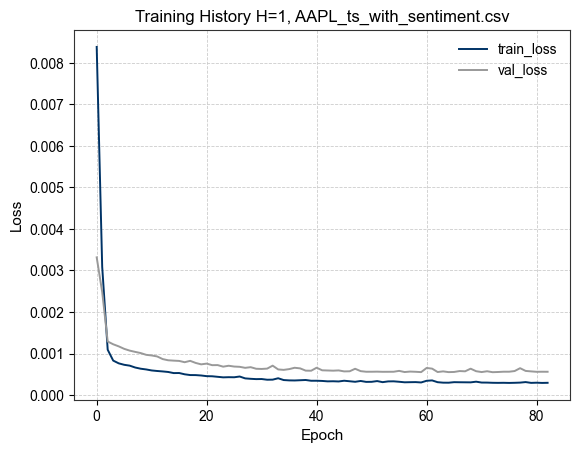

In [19]:
history_json = ckpt_path.replace(".pt", "_history.json")
plot_history_from_json(history_json, title=f"H={H}, {os.path.basename(CSV_PATH)}")

In [20]:
# --- Test-Auswertung ---

yhat_scaled = model.predict_multi_horizon(
    X_te,
    batch_size=int(train_cfg["batch_size"]),
    verbose=0,
)  # [N, H]

ytrue_scaled = y_te.squeeze(-1)    # [N, H]

rmse_scaled = rmse(ytrue_scaled, yhat_scaled)
r2_scaled = r2(ytrue_scaled, yhat_scaled)

print(f"[TEST - SCALED] RMSE={rmse_scaled:.6f} | R2={r2_scaled:.6f}")

if NORMALISE:
    yhat_scaled_3d = yhat_scaled[..., None]  # [N, H, 1]
    ytrue_scaled_3d = y_te                   # [N, H, 1]

    if NORM_METHOD == "percentage":
        yhat_level = dl.denormalise(
            yhat_scaled_3d,
            method="percentage",
            base_values=bT_te,   # [N, 1]
            normalise=True,
        ).squeeze(-1)            # [N, H]

        ytrue_level = dl.denormalise(
            ytrue_scaled_3d,
            method="percentage",
            base_values=bT_te,
            normalise=True,
        ).squeeze(-1)

    elif NORM_METHOD == "minmax":
        yhat_level = dl.denormalise(
            yhat_scaled_3d,
            method="minmax",
            base_values=None,
            normalise=True,
        ).squeeze(-1)

        ytrue_level = dl.denormalise(
            ytrue_scaled_3d,
            method="minmax",
            base_values=None,
            normalise=True,
        ).squeeze(-1)
    else:
        raise ValueError(f"Unbekannte Normalisierungsmethode: {NORM_METHOD}")

    rmse_level = rmse(ytrue_level, yhat_level)
    r2_level = r2(ytrue_level, yhat_level)

    print(f"[TEST - LEVEL]  RMSE={rmse_level:.6f} | R2={r2_level:.6f}")

else:
    print("[TEST] NORMALISE=False → SCALED-Werte entsprechen Originalskala.")


[TEST - SCALED] RMSE=0.017231 | R2=0.980132
[TEST - LEVEL]  RMSE=2.929647 | R2=0.991308


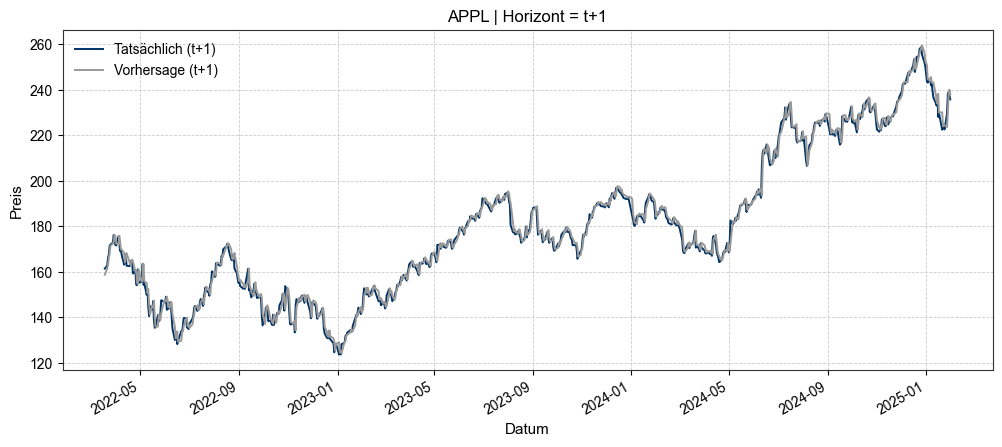

In [21]:
if STRIDE == 1:
    # ---------------------------------------------------------
    # Mode 1: stride=1 → zeige nur den letzten Horizont t+H
    # ---------------------------------------------------------
    h_idx = H - 1  # last horizon index (t+H)

    dates_h = dates_te[:, h_idx]        # [N]
    true_h  = ytrue_level[:, h_idx]     # [N]
    pred_h  = yhat_level[:, h_idx]      # [N]

    plt.figure(figsize=(12, 5))
    plt.plot(dates_h, true_h, label=f"Tatsächlich (t+{H})")
    plt.plot(dates_h, pred_h, label=f"Vorhersage (t+{H})")
    plt.title(f"{"APPL"} | Horizont = t+{H}")
    plt.xlabel("Datum")
    plt.ylabel("Preis")
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.show()

else:
    # ---------------------------------------------------------
    # Mode 2: stride > 1 → nutze ALLE Horizons,
    # fasse sie zu EINER Zeitreihe pro Kurve zusammen.
    # Doppelte Dates werden gemittelt.
    # Beispiel: H=15, stride=15 → alle 15 Prediction-Schritte
    #           als eine durchgehende Linie.
    # ---------------------------------------------------------
    # dates_te:      [N, H]
    # ytrue_level:   [N, H]
    # yhat_level:    [N, H]

    dates_flat = dates_te.reshape(-1)
    true_flat  = ytrue_level.reshape(-1)
    pred_flat  = yhat_level.reshape(-1)

    df_plot = pd.DataFrame({
        "date": dates_flat,
        "true": true_flat,
        "pred": pred_flat,
    })

    df_plot = df_plot.groupby("date", as_index=True).mean().sort_index()

    plt.figure(figsize=(12, 5))
    plt.plot(df_plot.index, df_plot["true"], label="True (all horizons)")
    plt.plot(df_plot.index, df_plot["pred"], label="Pred (all horizons)")
    plt.title(f"{os.path.basename(CSV_PATH)} | H={H}, stride={STRIDE} (merged series)")
    plt.xlabel("Datum")
    plt.ylabel("Preis")
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()
    plt.show()
